<a href="https://colab.research.google.com/github/JozefSL/EIA/blob/main/hourlyNGgenerationTX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

excel_url = 'https://www.eia.gov/electricity/gridmonitor/knownissues/xls/Region_TEX.xlsx'

try:
    df = pd.read_excel(excel_url)
    print("Data imported successfully!")
    display(df.head())
except Exception as e:
    print(f"Error importing data: {e}")

Data imported successfully!


,Region,UTC time,Local date,Hour,Local time,Time zone,Demand forecast,Demand,Net generation,Total interchange,...,CO2 Emissions: OIL,CO2 Emissions: Other,CO2 Emissions Generated,CO2 Emissions Imported,CO2 Emissions Exported,CO2 Emissions Consumed,Positive Generation,Consumed Electricity,CO2 Emissions Intensity for Generated Electricity,CO2 Emissions Intensity for Consumed Electricity
0,TEX,2015-07-01 06:00:00,2015-07-01,1,2015-07-01 01:00:00,Central,39708.0,37456.0,37462.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TEX,2015-07-01 07:00:00,2015-07-01,2,2015-07-01 02:00:00,Central,37338.0,35119.0,35124.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TEX,2015-07-01 08:00:00,2015-07-01,3,2015-07-01 03:00:00,Central,35697.0,33638.0,33642.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TEX,2015-07-01 09:00:00,2015-07-01,4,2015-07-01 04:00:00,Central,34772.0,32798.0,32805.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TEX,2015-07-01 10:00:00,2015-07-01,5,2015-07-01 05:00:00,Central,34773.0,32805.0,32812.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
#df.tail()

In [6]:
df['year'] = df['UTC time'].dt.year
df = df.sort_values(by=['Region', 'year', 'UTC time']).reset_index(drop=True)

df['NG_NG_hourly_diff'] = df.groupby(['Region', 'year'])['NG: NG'].diff()

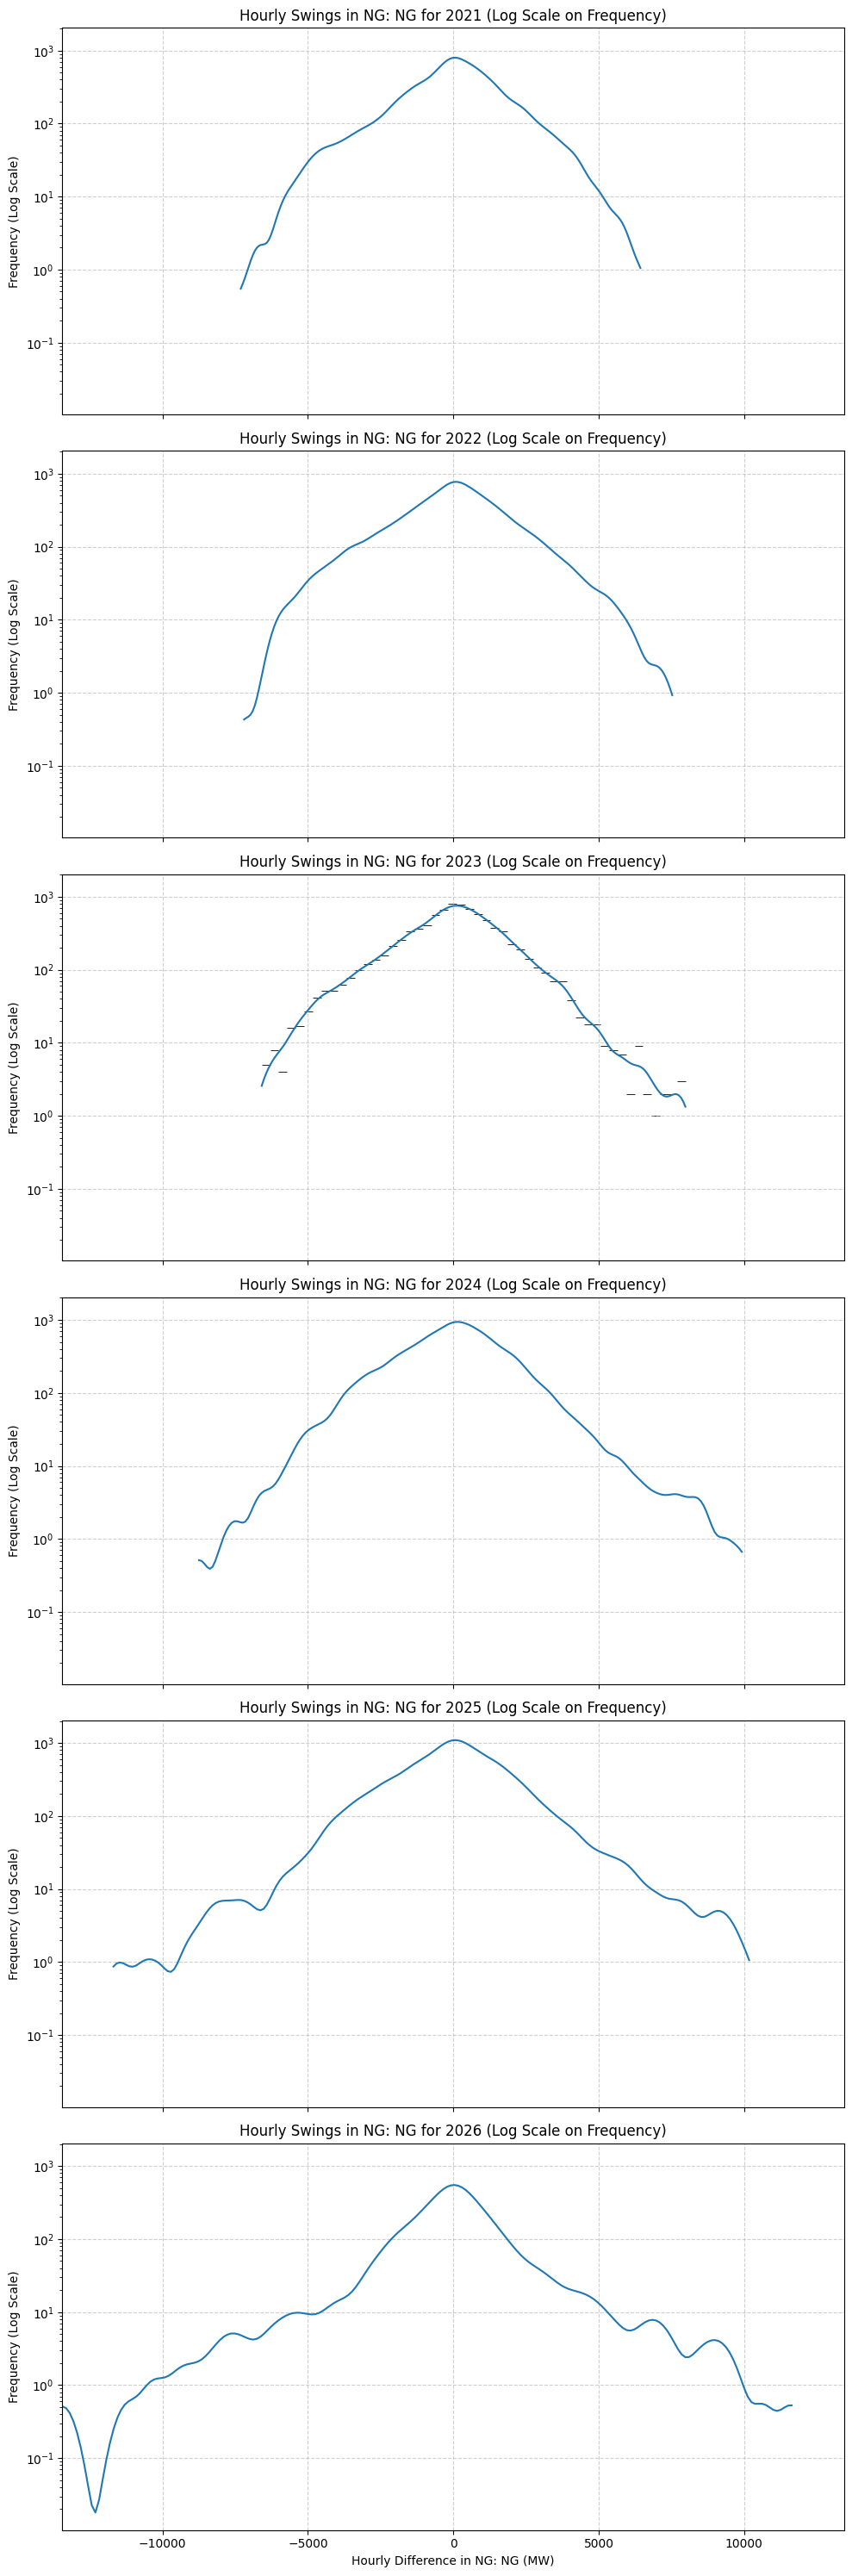

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for years 2021 and higher
df_filtered = df[df['year'] >= 2021]

# Get unique years for plotting from the filtered data
years = df_filtered['year'].unique()

# Calculate the maximum absolute difference for symmetric x-axis limits
max_abs_diff = df_filtered['NG_NG_hourly_diff'].abs().max()

# Create a figure and a set of subplots based on the number of years
# Set sharey=True to ensure all y-axes have the same scale
num_years = len(years)
fig, axes = plt.subplots(nrows=num_years, ncols=1, figsize=(10, 5 * num_years), sharex=True, sharey=True)

# If there's only one year, axes might not be an array, so make it one for consistent iteration
if num_years == 1:
    axes = [axes]

for i, year in enumerate(years):
    # Filter data for the current year from the filtered DataFrame
    year_data = df_filtered[df_filtered['year'] == year]

    # Plot histogram on the corresponding subplot with log scale for frequency only
    sns.histplot(year_data['NG_NG_hourly_diff'].dropna(), bins=50, kde=True, ax=axes[i], log_scale=(False, True))
    axes[i].set_title(f'Hourly Swings in NG: NG for {year} (Log Scale on Frequency)')
    axes[i].set_xlabel('Hourly Difference in NG: NG (MW)')
    axes[i].set_ylabel('Frequency (Log Scale)')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    # Set symmetric x-axis limits
    axes[i].set_xlim(-max_abs_diff, max_abs_diff)

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

# Find the largest positive swing
max_swing_row = df_filtered.loc[df_filtered['NG_NG_hourly_diff'].idxmax()]
max_swing_value = max_swing_row['NG_NG_hourly_diff']
max_swing_time = max_swing_row['UTC time']

# Find the largest negative swing
min_swing_row = df_filtered.loc[df_filtered['NG_NG_hourly_diff'].idxmin()]
min_swing_value = min_swing_row['NG_NG_hourly_diff']
min_swing_time = min_swing_row['UTC time']

# Create a DataFrame to display the results
swing_data = {
    'Swing Type': ['Largest Positive Swing', 'Largest Negative Swing'],
    'Swing Value (MW)': [max_swing_value, min_swing_value],
    'UTC Time': [max_swing_time, min_swing_time]
}

swing_df = pd.DataFrame(swing_data)
display(swing_df)

,Swing Type,Swing Value (MW),UTC Time
0,Largest Positive Swing,11633.0,2026-02-01 00:00:00
1,Largest Negative Swing,-13441.0,2026-01-28 16:00:00


In [14]:
import pandas as pd

years = df_filtered['year'].unique()
annual_swings = []

for year in sorted(years):
    year_data = df_filtered[df_filtered['year'] == year]

    if not year_data.empty:
        # Largest Positive Swing for the year
        max_swing_row_year = year_data.loc[year_data['NG_NG_hourly_diff'].idxmax()]
        annual_swings.append({
            'Year': year,
            'Swing Type': 'Largest Positive Swing',
            'Swing Value (MW)': max_swing_row_year['NG_NG_hourly_diff'],
            'UTC Time': max_swing_row_year['UTC time']
        })

        # Largest Negative Swing for the year
        min_swing_row_year = year_data.loc[year_data['NG_NG_hourly_diff'].idxmin()]
        annual_swings.append({
            'Year': year,
            'Swing Type': 'Largest Negative Swing',
            'Swing Value (MW)': min_swing_row_year['NG_NG_hourly_diff'],
            'UTC Time': min_swing_row_year['UTC time']
        })

annual_swings_df = pd.DataFrame(annual_swings)
display(annual_swings_df)

,Year,Swing Type,Swing Value (MW),UTC Time
0,2021,Largest Positive Swing,6432.0,2021-09-04 17:00:00
1,2021,Largest Negative Swing,-7309.0,2021-02-15 09:00:00
2,2022,Largest Positive Swing,7527.0,2022-12-15 00:00:00
3,2022,Largest Negative Swing,-7196.0,2022-04-21 04:00:00
4,2023,Largest Positive Swing,7979.0,2023-12-30 00:00:00
5,2023,Largest Negative Swing,-6589.0,2023-05-09 04:00:00
6,2024,Largest Positive Swing,9918.0,2024-01-13 00:00:00
7,2024,Largest Negative Swing,-8746.0,2024-02-13 15:00:00
8,2025,Largest Positive Swing,10171.0,2025-01-20 00:00:00
9,2025,Largest Negative Swing,-11686.0,2025-12-31 16:00:00


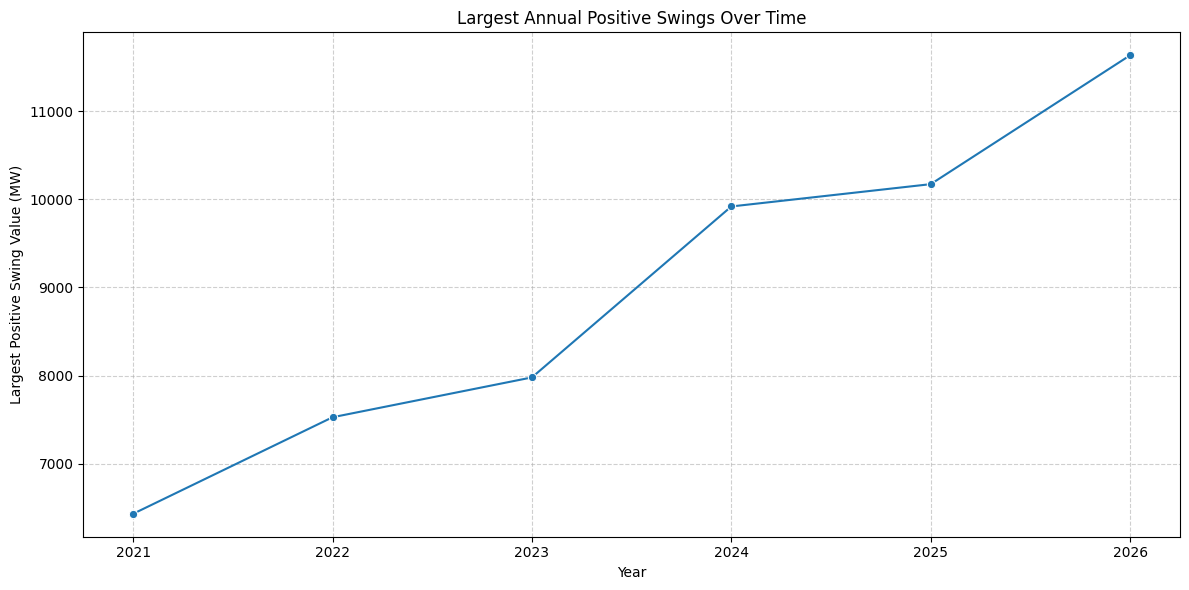

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for largest positive swings
positive_swings = annual_swings_df[annual_swings_df['Swing Type'] == 'Largest Positive Swing']

plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Swing Value (MW)', data=positive_swings, marker='o')
plt.title('Largest Annual Positive Swings Over Time')
plt.xlabel('Year')
plt.ylabel('Largest Positive Swing Value (MW)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(positive_swings['Year'].unique()) # Ensure all years are shown on x-axis
plt.tight_layout()
plt.show()

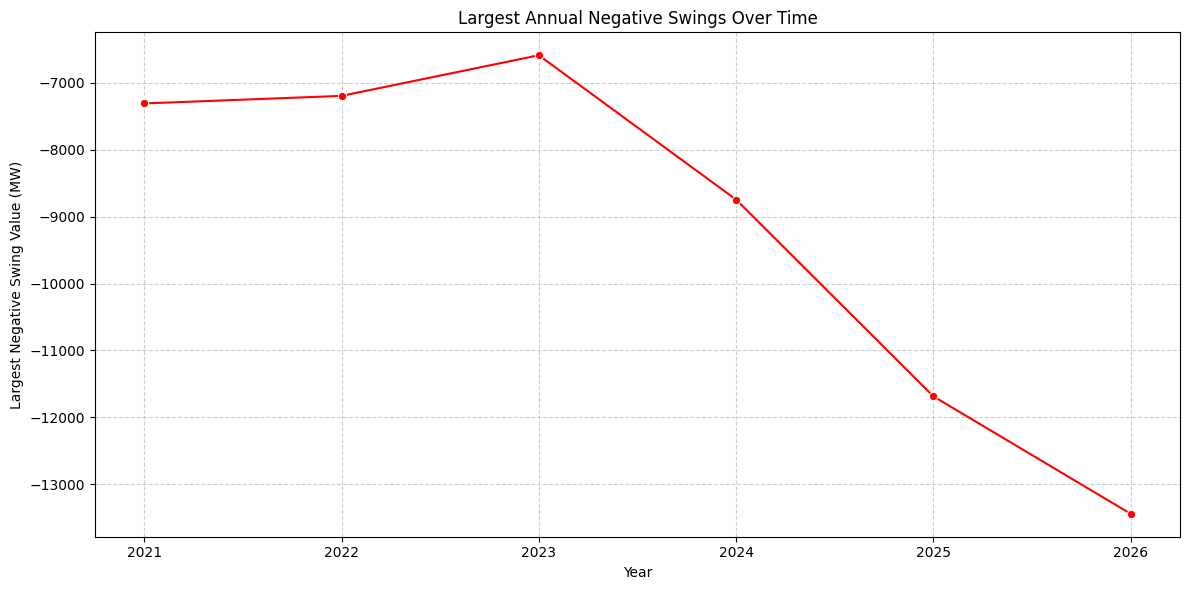

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for largest negative swings
negative_swings = annual_swings_df[annual_swings_df['Swing Type'] == 'Largest Negative Swing']

plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Swing Value (MW)', data=negative_swings, marker='o', color='red')
plt.title('Largest Annual Negative Swings Over Time')
plt.xlabel('Year')
plt.ylabel('Largest Negative Swing Value (MW)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(negative_swings['Year'].unique()) # Ensure all years are shown on x-axis
plt.tight_layout()
plt.show()

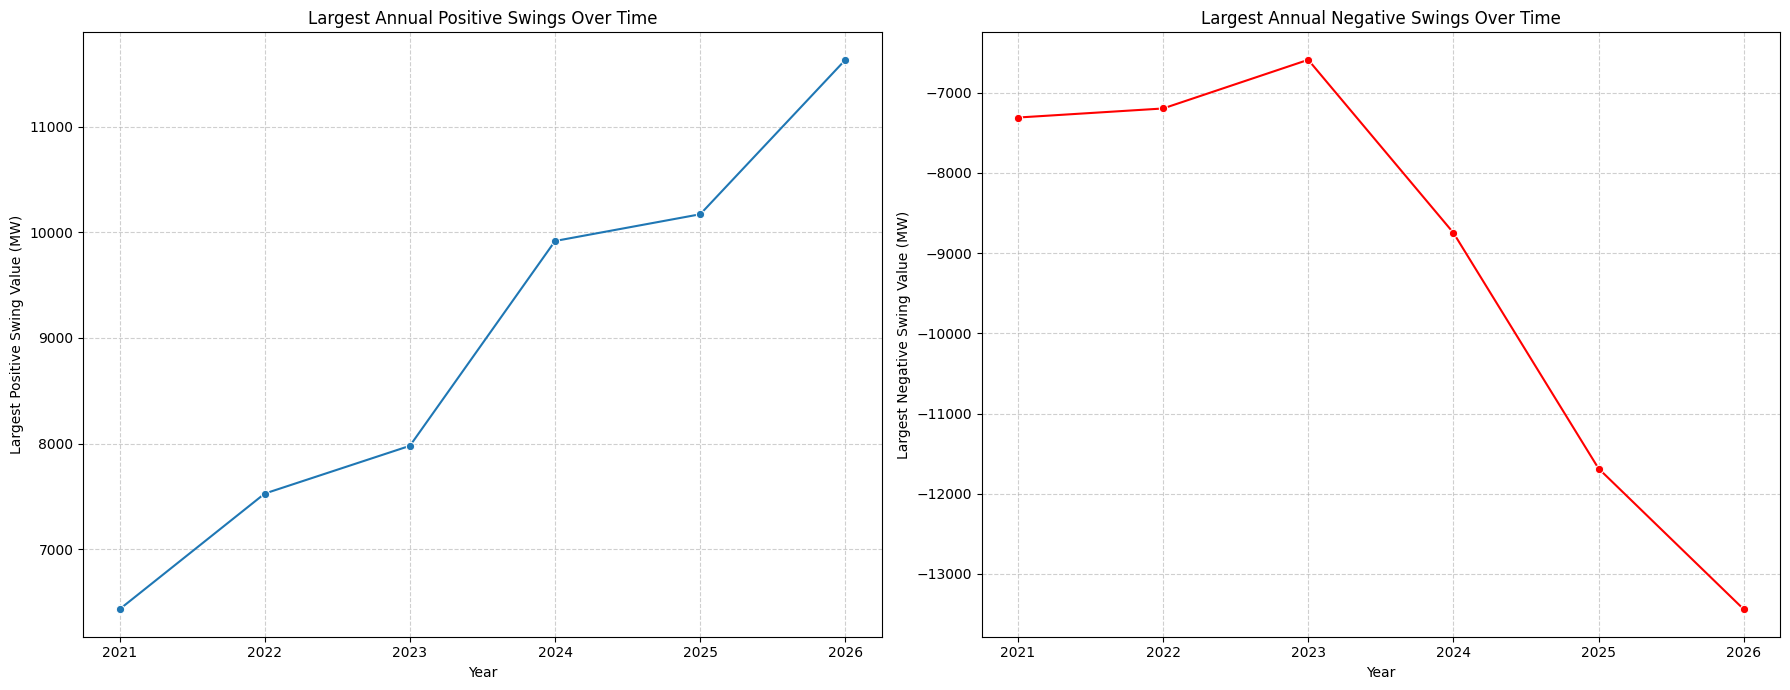

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
positive_swings = annual_swings_df[annual_swings_df['Swing Type'] == 'Largest Positive Swing']
negative_swings = annual_swings_df[annual_swings_df['Swing Type'] == 'Largest Negative Swing']

# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot Largest Annual Positive Swings
sns.lineplot(x='Year', y='Swing Value (MW)', data=positive_swings, marker='o', ax=axes[0])
axes[0].set_title('Largest Annual Positive Swings Over Time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Largest Positive Swing Value (MW)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xticks(positive_swings['Year'].unique())

# Plot Largest Annual Negative Swings
sns.lineplot(x='Year', y='Swing Value (MW)', data=negative_swings, marker='o', color='red', ax=axes[1])
axes[1].set_title('Largest Annual Negative Swings Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Largest Negative Swing Value (MW)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xticks(negative_swings['Year'].unique())

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [25]:
# Get the index of the largest positive swing from the original DataFrame
max_swing_idx = max_swing_row.name

# Calculate the start and end indices for the 11 rows (5 before, 1 at, 5 after)
start_idx_pos = max(0, max_swing_idx - 5)
end_idx_pos = min(len(df), max_swing_idx + 6)

# Select and display the rows for the largest positive swing
print(f"Rows surrounding the largest positive swing (Index: {max_swing_idx}, Value: {max_swing_row['NG_NG_hourly_diff']}):")
display(df[['Region','UTC time','Demand','NG: NG']].iloc[start_idx_pos:end_idx_pos])

# Get the index of the largest negative swing from the original DataFrame
min_swing_idx = min_swing_row.name

# Calculate the start and end indices for the 11 rows (5 before, 1 at, 5 after)
start_idx_neg = max(0, min_swing_idx - 5)
end_idx_neg = min(len(df), min_swing_idx + 6)

# Select and display the rows for the largest negative swing
print(f"\nRows surrounding the largest negative swing (Index: {min_swing_idx}, Value: {min_swing_row['NG_NG_hourly_diff']}):")
display(df[['Region','UTC time','Demand','NG: NG']].iloc[start_idx_neg:end_idx_neg])

Rows surrounding the largest positive swing (Index: 92826, Value: 11633.0):


,Region,UTC time,Demand,NG: NG
92821,TEX,2026-01-31 19:00:00,62606.0,17530.0
92822,TEX,2026-01-31 20:00:00,60292.0,16946.0
92823,TEX,2026-01-31 21:00:00,58315.0,16423.0
92824,TEX,2026-01-31 22:00:00,57604.0,16523.0
92825,TEX,2026-01-31 23:00:00,58022.0,19936.0
92826,TEX,2026-02-01 00:00:00,59770.0,31569.0
92827,TEX,2026-02-01 01:00:00,62370.0,35935.0
92828,TEX,2026-02-01 02:00:00,63658.0,37160.0
92829,TEX,2026-02-01 03:00:00,64372.0,37447.0
92830,TEX,2026-02-01 04:00:00,64645.0,37732.0



Rows surrounding the largest negative swing (Index: 92746, Value: -13441.0):


,Region,UTC time,Demand,NG: NG
92741,TEX,2026-01-28 11:00:00,61393.0,40567.0
92742,TEX,2026-01-28 12:00:00,63780.0,41052.0
92743,TEX,2026-01-28 13:00:00,66528.0,41975.0
92744,TEX,2026-01-28 14:00:00,67941.0,44425.0
92745,TEX,2026-01-28 15:00:00,66877.0,38088.0
92746,TEX,2026-01-28 16:00:00,64478.0,24647.0
92747,TEX,2026-01-28 17:00:00,60892.0,19035.0
92748,TEX,2026-01-28 18:00:00,57637.0,16932.0
92749,TEX,2026-01-28 19:00:00,55025.0,15393.0
92750,TEX,2026-01-28 20:00:00,53275.0,14747.0
